In [ ]:
!pip install -q segmentation-models-pytorch
!pip install -q albumentations
!pip install -q torchmetrics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 22.6 MB/s eta 0:00:00


In [ ]:
import os
import cv2
import torch
import numpy as np
import matplotlib.pyplot as plt

from PIL import Image
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split

import albumentations as A
import segmentation_models_pytorch as smp

import torch.nn as nn
import torch.optim as optim

from torchmetrics.classification import MulticlassAccuracy
from torchmetrics.classification import MulticlassPrecision
from torchmetrics.classification import MulticlassRecall
from torchmetrics.classification import MulticlassF1Score
from torchmetrics.classification import MulticlassJaccardIndex

In [ ]:
IMAGE_DIR = "/content/drive/MyDrive/ADH-Dataset/v0.3 Model Dataset/dental_caries/images"
MASK_DIR = "/content/drive/MyDrive/ADH-Dataset/v0.3 Model Dataset/dental_caries/masks"

In [ ]:
CLASS_NAMES = {
    0: "Background",
    1: "Bone",
    2: "Decayed Teeth",
    3: "Healthy Teeth",
    4: "Implant Teeth",
    5: "Restored Teeth"
}

NUM_CLASSES = len(CLASS_NAMES)

print("Images:", len(os.listdir(IMAGE_DIR)))
print("Masks:", len(os.listdir(MASK_DIR)))

Images: 2953
Masks: 2953


In [ ]:
pixel_counts = np.zeros(NUM_CLASSES)

for file in os.listdir(MASK_DIR):
    mask = np.array(Image.open(os.path.join(MASK_DIR, file)).convert("L"))
    for i in range(NUM_CLASSES):
        pixel_counts[i] += np.sum(mask == i)

pixel_counts = np.where(pixel_counts == 0, 1, pixel_counts)
total_pixels = np.sum(pixel_counts)

class_weights = np.log(1 + (total_pixels / pixel_counts))
class_weights = class_weights / np.sum(class_weights) * NUM_CLASSES
class_weights = torch.tensor(class_weights, dtype=torch.float32)

print("Class Weights:", class_weights)

Class Weights: tensor([0.8237, 0.6185, 1.0022, 0.7389, 1.9823, 0.8344])


In [ ]:
images = os.listdir(IMAGE_DIR)

train, val = train_test_split(images, test_size=0.2, random_state=42)
val, test = train_test_split(val, test_size=0.5, random_state=42)

In [ ]:
train_transform = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.Rotate(limit=20, p=0.5),
    A.RandomBrightnessContrast(p=0.3)
])

val_transform = A.Compose([])

In [ ]:
class DentalDataset(Dataset):
    def __init__(self, file_list, transform=None):
        self.files = file_list
        self.transform = transform

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        name = self.files[idx]

        img_path = os.path.join(IMAGE_DIR, name)
        mask_path = os.path.join(MASK_DIR, os.path.splitext(name)[0] + ".png")

        image = cv2.imread(img_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        mask = cv2.imread(mask_path, 0)

        # ✅ STRICT 512
        image = cv2.resize(image, (512, 512))
        mask = cv2.resize(mask, (512, 512), interpolation=cv2.INTER_NEAREST)

        if self.transform:
            aug = self.transform(image=image, mask=mask)
            image, mask = aug["image"], aug["mask"]

        image = image.astype(np.float32) / 255.0

        mean = np.array([0.485, 0.456, 0.406])
        std = np.array([0.229, 0.224, 0.225])

        image = (image - mean) / std
        image = np.transpose(image, (2, 0, 1))

        return torch.tensor(image, dtype=torch.float32), torch.tensor(mask, dtype=torch.long)

In [ ]:
train_loader = DataLoader(DentalDataset(train, train_transform), batch_size=8, shuffle=True, num_workers=2, pin_memory=True)
val_loader = DataLoader(DentalDataset(val, val_transform), batch_size=8, num_workers=2, pin_memory=True)
test_loader = DataLoader(DentalDataset(test, val_transform), batch_size=8, num_workers=2, pin_memory=True)

In [ ]:
model = smp.Unet(
    encoder_name="resnet50",
    encoder_weights="imagenet",
    in_channels=3,
    classes=NUM_CLASSES
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/156 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/102M [00:00<?, ?B/s]

In [ ]:
ce_loss = nn.CrossEntropyLoss(weight=class_weights.to(device))
dice_loss = smp.losses.DiceLoss(mode="multiclass")

class FocalLoss(nn.Module):
    def __init__(self, alpha=None, gamma=2):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.ce = nn.CrossEntropyLoss(weight=alpha, reduction='none')

    def forward(self, preds, targets):
        ce_loss = self.ce(preds, targets)
        pt = torch.exp(-ce_loss)
        focal_loss = ((1 - pt) ** self.gamma) * ce_loss
        return focal_loss.mean()

focal_loss = FocalLoss(alpha=class_weights.to(device), gamma=2)

# ✅ FINAL COMBINED LOSS
def loss_fn(pred, mask):
    return 0.4 * ce_loss(pred, mask) + 0.3 * dice_loss(pred, mask) + 0.3 * focal_loss(pred, mask)

In [ ]:
optimizer = optim.AdamW(model.parameters(), lr=1e-4)

In [ ]:
accuracy = MulticlassAccuracy(num_classes=NUM_CLASSES).to(device)
precision = MulticlassPrecision(num_classes=NUM_CLASSES).to(device)
recall = MulticlassRecall(num_classes=NUM_CLASSES).to(device)
f1 = MulticlassF1Score(num_classes=NUM_CLASSES).to(device)
iou = MulticlassJaccardIndex(num_classes=NUM_CLASSES).to(device)

In [ ]:
def train_epoch(loader):
    model.train()
    total_loss = 0

    for imgs, masks in loader:
        imgs, masks = imgs.to(device), masks.to(device)

        optimizer.zero_grad()
        preds = model(imgs)
        loss = loss_fn(preds, masks)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    return total_loss / len(loader)


def validate(loader):
    model.eval()
    total_loss = 0

    with torch.no_grad():
        for imgs, masks in loader:
            imgs, masks = imgs.to(device), masks.to(device)
            preds = model(imgs)
            loss = loss_fn(preds, masks)
            total_loss += loss.item()

    return total_loss / len(loader)

In [ ]:
EPOCHS = 30

for epoch in range(EPOCHS):
    train_loss = train_epoch(train_loader)
    val_loss = validate(val_loader)

    print(f"Epoch {epoch+1}/{EPOCHS} | Train: {train_loss:.4f} | Val: {val_loss:.4f}")

Epoch 1/30 | Train: 0.6045 | Val: 0.4554
Epoch 2/30 | Train: 0.4262 | Val: 0.4064
Epoch 3/30 | Train: 0.3843 | Val: 0.3934
Epoch 4/30 | Train: 0.3606 | Val: 0.3835
Epoch 5/30 | Train: 0.3406 | Val: 0.3686
Epoch 6/30 | Train: 0.3269 | Val: 0.3670
Epoch 7/30 | Train: 0.3160 | Val: 0.3590
Epoch 8/30 | Train: 0.3042 | Val: 0.3523
Epoch 9/30 | Train: 0.2930 | Val: 0.3476
Epoch 10/30 | Train: 0.2874 | Val: 0.3471
Epoch 11/30 | Train: 0.2807 | Val: 0.3489
Epoch 12/30 | Train: 0.2740 | Val: 0.3540
Epoch 13/30 | Train: 0.2646 | Val: 0.3621
Epoch 14/30 | Train: 0.2531 | Val: 0.3723
Epoch 15/30 | Train: 0.2536 | Val: 0.3599
Epoch 16/30 | Train: 0.2428 | Val: 0.4128
Epoch 17/30 | Train: 0.2437 | Val: 0.3631
Epoch 18/30 | Train: 0.2258 | Val: 0.3655
Epoch 19/30 | Train: 0.2176 | Val: 0.3845
Epoch 20/30 | Train: 0.2146 | Val: 0.3713
Epoch 21/30 | Train: 0.2038 | Val: 0.3936
Epoch 22/30 | Train: 0.2040 | Val: 0.3875
Epoch 23/30 | Train: 0.1935 | Val: 0.3816
Epoch 24/30 | Train: 0.1887 | Val: 0.4067
E

In [ ]:
model.eval()

for imgs, masks in test_loader:
    imgs, masks = imgs.to(device), masks.to(device)

    preds = model(imgs)
    preds = torch.argmax(preds, dim=1)

    accuracy.update(preds, masks)
    precision.update(preds, masks)
    recall.update(preds, masks)
    f1.update(preds, masks)
    iou.update(preds, masks)

print("Accuracy:", accuracy.compute().item())
print("Precision:", precision.compute().item())
print("Recall:", recall.compute().item())
print("F1:", f1.compute().item())
print("IoU:", iou.compute().item())

Accuracy: 0.7864658832550049
Precision: 0.7936160564422607
Recall: 0.7864658832550049
F1: 0.7874062061309814
IoU: 0.6757234334945679


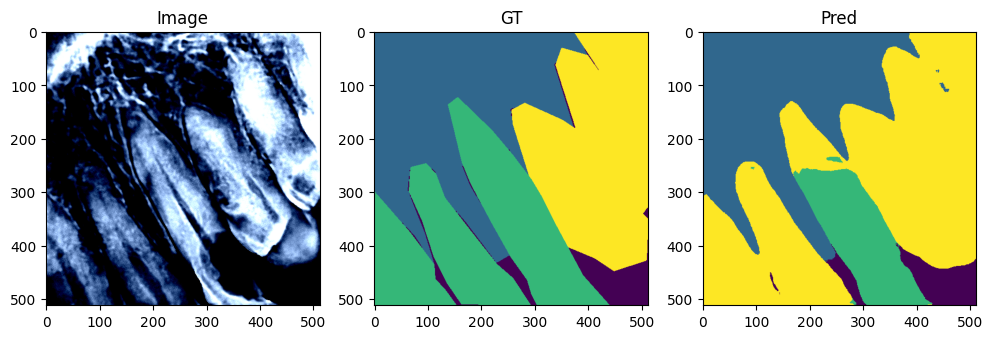

In [ ]:
imgs, masks = next(iter(test_loader))
imgs = imgs.to(device)

preds = model(imgs)
preds = torch.argmax(preds, dim=1).cpu()

plt.figure(figsize=(12, 4))

plt.subplot(1,3,1)
plt.title("Image")
plt.imshow(np.transpose(imgs[0].cpu(), (1,2,0)))

plt.subplot(1,3,2)
plt.title("GT")
plt.imshow(masks[0])

plt.subplot(1,3,3)
plt.title("Pred")
plt.imshow(preds[0])

plt.show()


In [ ]:
torch.save(model.state_dict(), "dental_unet_resnet50.pth")